In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patchs # 円描画に必要


# 参照渡しに注意

In [3]:
x = np.array([1, 2, 3])
y = x # 参照渡し
print(x)
print(y)

x[1] = 0
print(x)
print(y)


[1 2 3]
[1 2 3]
[1 0 3]
[1 0 3]


In [5]:
# 値渡し
x = np.array([1, 2, 3])
y = x.copy()

x[1] = 0
print(x)
print(y)


[1 0 3]
[1 2 3]


## テンソルからndarrayへ変換しても参照渡しになる．

In [7]:
x1 = torch.ones(5)
print(x1)

x2 = x1.data.numpy() # テンソルからndarray
print(x2)
print()

x1[0] = 3.14
print(x1)
print(x2)
print('😱')


tensor([1., 1., 1., 1., 1.])
[1. 1. 1. 1. 1.]

tensor([3.1400, 1.0000, 1.0000, 1.0000, 1.0000])
[3.14 1.   1.   1.   1.  ]
😱


In [8]:
x1 = torch.ones(5)
x2 = x1.data.numpy().copy() # 安全に値渡し

x1[0] = 3.14
print(x1)
print(x2)


tensor([3.1400, 1.0000, 1.0000, 1.0000, 1.0000])
[1. 1. 1. 1. 1.]


# 合成関数の実装

## 普通の関数

In [9]:
def f(x):
    return (2 * x**2 + 2)

x = np.arange(-2, 2.1, 0.25) # arangeは，stopを含まない仕様．
print(x)

y = f(x)
print(y)


[-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.  ]
[10.     8.125  6.5    5.125  4.     3.125  2.5    2.125  2.     2.125
  2.5    3.125  4.     5.125  6.5    8.125 10.   ]


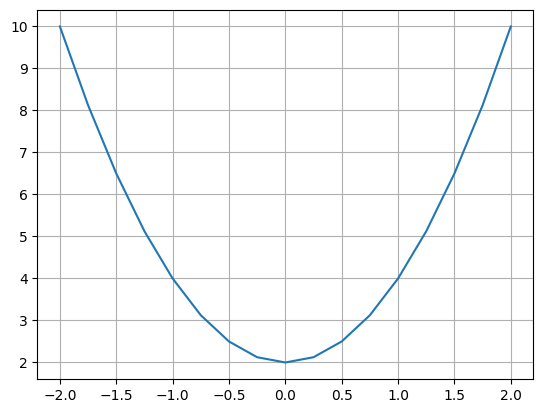

In [10]:
plt.plot(x, y)
plt.grid()
plt.show()


## 合成関数の実装

[10.     8.125  6.5    5.125  4.     3.125  2.5    2.125  2.     2.125
  2.5    3.125  4.     5.125  6.5    8.125 10.   ]


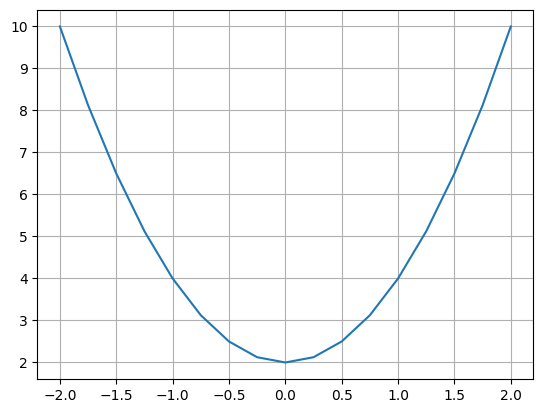

In [11]:
def f1(x):
    return x**2

def f2(x):
    return 2 * x

def f3(x):
    return x + 2

x = np.arange(-2.0, 2.1, 0.25) # start, stop, step
y = f3(f2(f1(x)))
print(y)

plt.plot(x, y)
plt.grid()
plt.show()


# 数値微分

## 関数を微分する関数

In [12]:
def fdiff(f):
    """関数を微分する関数"""
    # 関数fを微分した結果の関数をdiffとして定義
    def diff(x):
        h = 1e-6
        return (f(x + h) - f(x - h)) / (2 * h)

    # fdiffの戻り値は微分した結果の関数diff
    return diff


[10.     8.125  6.5    5.125  4.     3.125  2.5    2.125  2.     2.125
  2.5    3.125  4.     5.125  6.5    8.125 10.   ]
[-8. -7. -6. -5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.  6.  7.  8.]


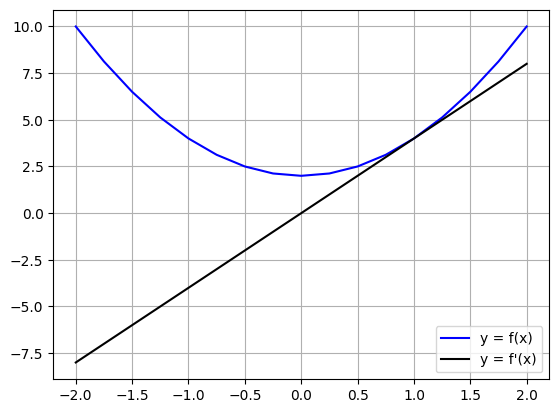

In [13]:
def f(x):
    """2次関数"""
    return (2 * x**2 + 2)

diff = fdiff(f) # 関数fを微分した関数を取得

x = np.arange(-2.0, 2.1, 0.25) # 
y = f(x)
y_dash = diff(x)
print(y)
print(y_dash)

plt.plot(x, y, label='y = f(x)', c='b')
plt.plot(x, y_dash, label="y = f'(x)", c='k')
plt.grid()
plt.legend()
plt.show()


## シグモイド関数の数値微分

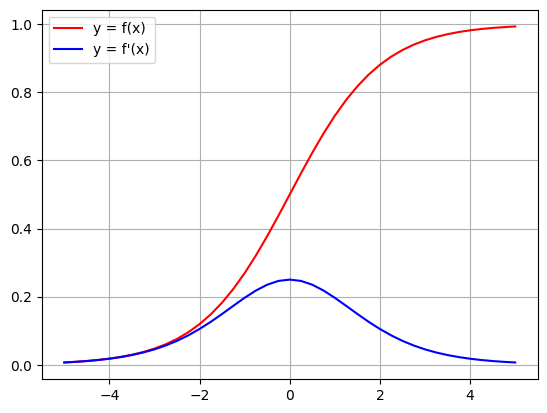

In [61]:
def fdiff(f):
    """引数で受け取った関数を微分した関数を返す関数"""
    def diff(x):
        h = 1e-6
        return (f(x + h) - f(x - h)) / (2 * h)
    
    return diff

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.1, 0.25) # arangeは，stopを含まない．
y = sigmoid(x)
# print(y)

diff = fdiff(sigmoid) # シグモイド関数の数値微分
y_dash = diff(x)

plt.plot(x, y, label='y = f(x)', c='r')
plt.plot(x, y_dash, label="y = f'(x)", c='b')
plt.legend()
plt.grid()
plt.show()


# カスタムクラス定義

## クラス

2 3
-1 -2


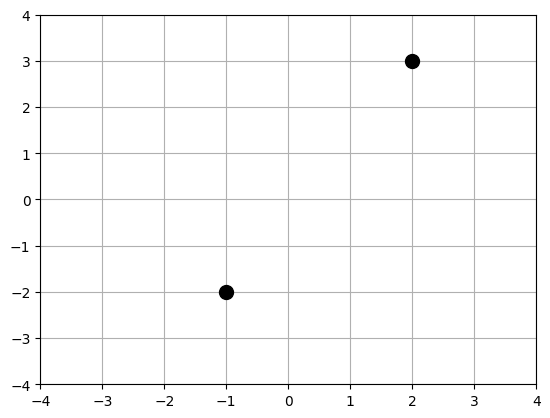

In [14]:
class Point():
    def __init__(self, x , y):
        # 属性
        self.x = x
        self.y = y
    
    def draw(self):
        plt.plot(self.x, self.y, marker='o', markersize=10, c='k')

p1 = Point(2, 3)
p2 = Point(-1, -2)

print(p1.x, p1.y)
print(p2.x, p2.y)

p1.draw()
p2.draw()
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid()
plt.show()


## クラスの継承

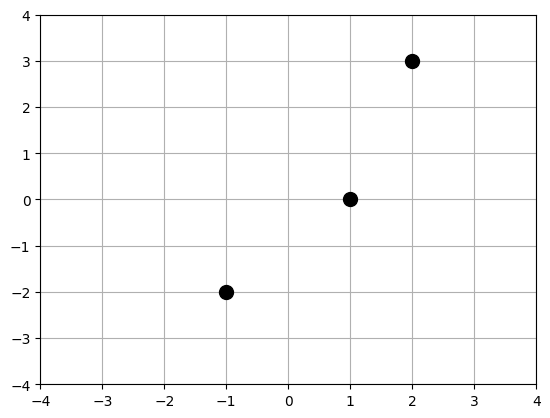

In [72]:
class Circle1(Point):
    """Pointの子クラス"""
    def __init__(self, x, y, r):
        super().__init__(x, y) # xとyは，親クラスの属性として設定．
        self.r = r

c1_1 = Circle1(1, 0, 2)

p1.draw()
p2.draw()
c1_1.draw()
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid()
plt.show()


## メソッドのオーバーライド

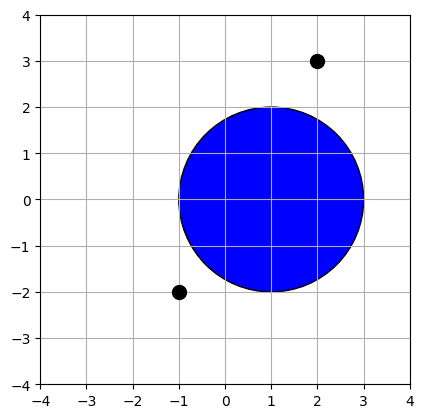

In [80]:
class Circle2(Point):
    def __init__(self, x, y, r):
        super().__init__(x, y)
        self.r = r
    
    def draw(self, ax):
        """親クラスのdrawメソッドをオーバーライド"""
        c = patchs.Circle(xy=(self.x, self.y), radius=self.r, fc='b', ec='k')
        ax.add_patch(c)

c2_1 = Circle2(1, 0, 2)

ax = plt.subplot()
ax.set_aspect('equal')
p1.draw()
p2.draw()
c2_1.draw(ax)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid()
plt.show()


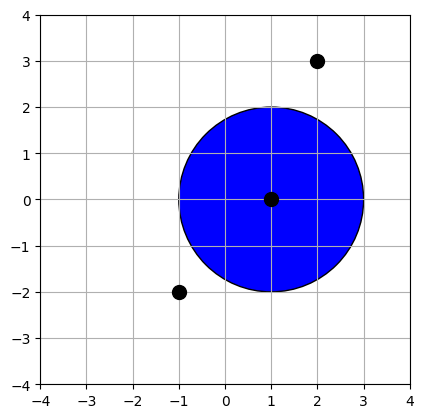

In [84]:
# 円の中心に点も打ちたいよね．
class Circle3(Point):
    def __init__(self, x, y, r):
        super().__init__(x, y)
        self.r = r
    
    def draw(self, ax):
        """親クラスのdrawメソッドをオーバーライド"""
        c = patchs.Circle(xy=(self.x, self.y), radius=self.r, fc='b', ec='k')
        ax.add_patch(c)

        super().draw()

c3_1 = Circle3(1, 0, 2)

ax = plt.subplot()
ax.set_aspect('equal')
p1.draw()
p2.draw()
c3_1.draw(ax)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid()
plt.show()


# クラスのインスタンスを関数扱いする方法

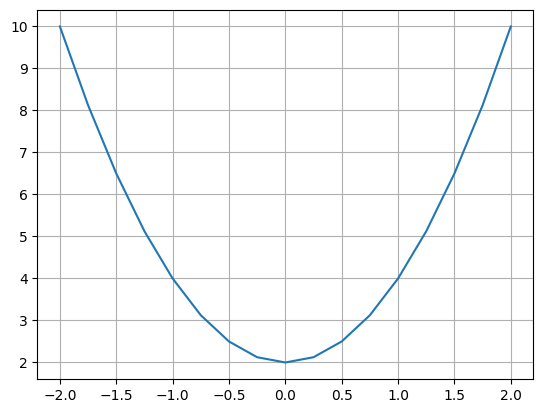

In [ ]:
class H():
    """
    クラスのインスタンスを関数扱いしたい場合，__call__の中に振る舞いを記述すればよい．
    __call__は，「状態を持った関数を作れること」が嬉しい．カスタムできる自販機のようなもの．
    """
    def __call__(self, x):
        return 2 * x**2 + 2

x = np.arange(-2.0, 2.1, 0.25)
h = H()
y = h(x)

plt.plot(x, y)
plt.grid()
plt.show()
